In [1]:
# import sys, os

# hostname = os.uname()[1]

# if "crc" in hostname:
#     scriptdir = "/cr/users/filip/bin/"
# elif "beep-boop" == hostname:
#     scriptdir = "/home/quizznor/projects/phd-thesis/bin/"

# sys.path.append(scriptdir)

from utils.binaries import *
from utils.plotting import *

# set_plt_style("script")

16:16:49 (   +1.3s) [INFO   ] -- import logging
16:16:50 (  +128ms) [INFO   ] -- import numpy as np
16:16:50 (    +9ms) [INFO   ] -- import uncertainties
16:16:50 (  +804ms) [INFO   ] -- import pandas as pd
16:16:50 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
16:16:50 (    +1ms) [INFO   ] -- import binaries.tools as tools
16:16:50 (    +2ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
16:16:50 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
16:16:50 (    +0ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
16:16:50 (    +1ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
16:16:50 (    +0ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
16:16:50 (    +1ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offline/install')
16:16:51 (  +438ms) [INFO   ] -- import matplotlib.pyplot as plt
16:16:51 (  +692ms) [INFO   ] -- import seabor

In [2]:
lgE, EJ, Err_up, Err_down = np.loadtxt("auger_icrc2021.txt", unpack=True)                       #   EJ in m^-2 s^-1 sr^-1
EJ *= 1e6 * (3600 * 24 * 365)                                                                   # now in km^-2 yr^-1 sr^-1
Err_up *= 1e6 * (3600 * 24 * 365) * ((10 ** lgE) ** 2) 
Err_down *= 1e6 * (3600 * 24 * 365) * ((10 ** lgE) ** 2)

def process_KCDC(data_path):

    lgE, J, Jerrlow, Jerrhigh, _, _ = np.loadtxt(data_path, unpack = True, delimiter=';')

    # J is in units of m^-2 yr^-1 sr^-1 eV^-1, we need to convert it
    E = 10 ** lgE
    EJ = E * (J * 1e6 * (3600 * 24 * 365))
    EJerrlow = E * (Jerrlow * 1e6 * (3600 * 24 * 365))
    EJerrhigh = E * (Jerrhigh * 1e6 * (3600 * 24 * 365))

    return E, EJ, EJerrlow, EJerrhigh

# def SpectrumICRC2021(E):

#     # data from https://pos.sissa.it/301/486/pdf
#     J0 = EJ[0] / E_true[0] 
#     J0 /= 6.5e3

#     E_ankle = 5.08e18
#     E_s = 3.9e19
#     gamma1 = 3.293
#     gamma2 = 2.53
#     deltaG = 2.5

#     J_below = lambda x: J0 * np.power(x/E_ankle,-gamma1)
#     J_above = lambda x: J0 * np.power(x/E_ankle,-gamma2) * (1 + np.power(E_ankle/E_s, deltaG)) / (1 + np.power(x/E_s, deltaG))

#     return np.piecewise(E, [E < E_ankle, E >= E_ankle], [J_below, J_above])

16:21:21 ( +259.2s) [DEBUG  ] -- font size set to 9.5
16:21:21 (    +1ms) [DEBUG  ] -- label size set to 13.0
16:21:21 (    +0ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
16:21:21 (    +1ms) [DEBUG  ] -- markersize set to 2.0
16:21:21 (    +0ms) [DEBUG  ] -- usetex set to False


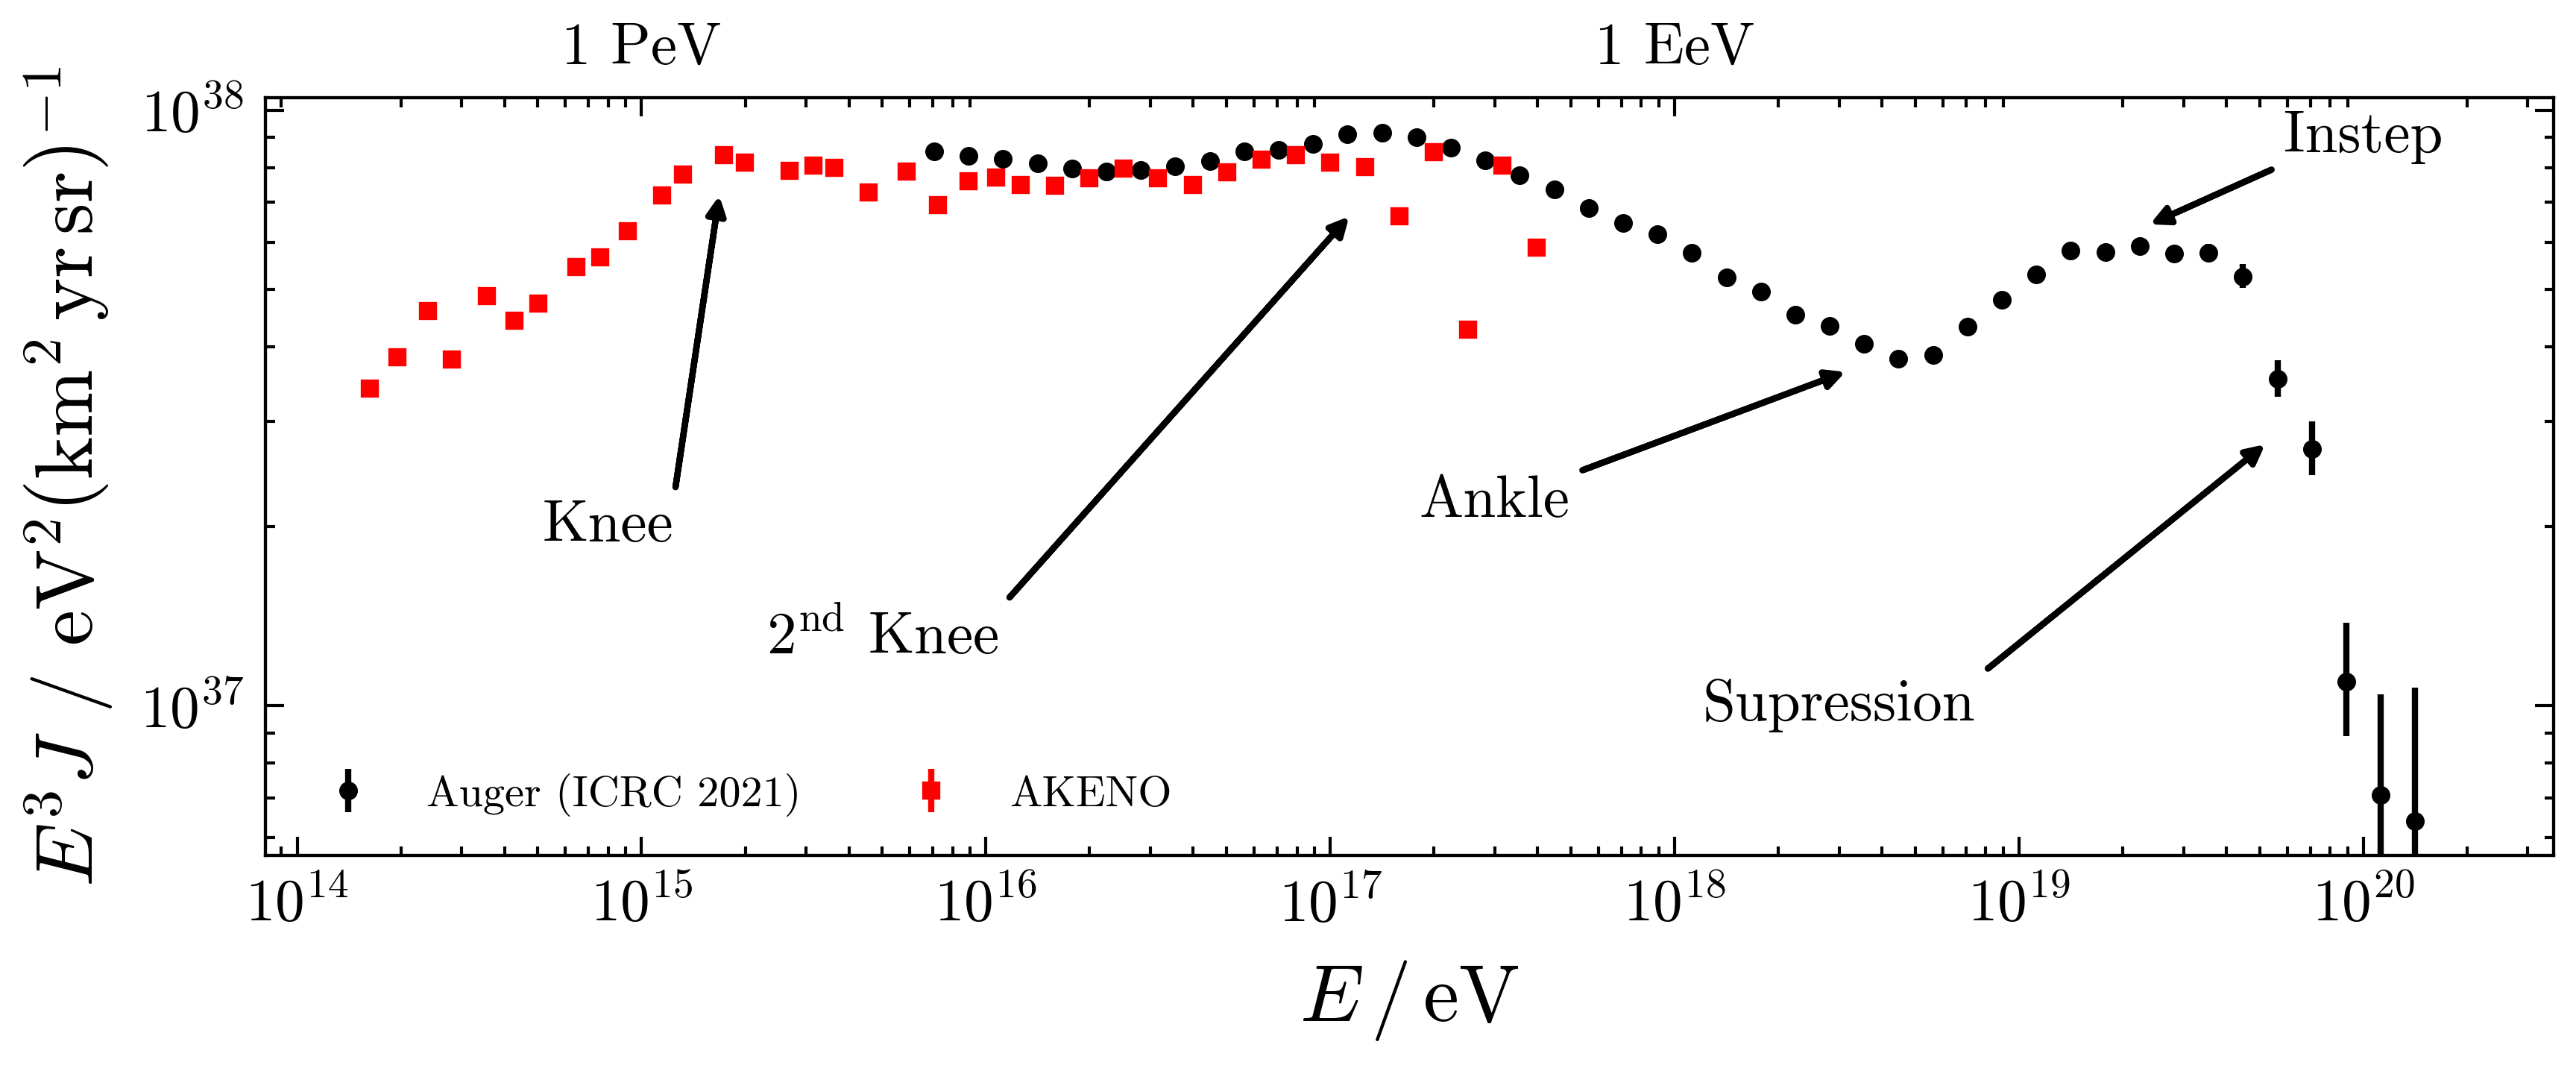

In [4]:
set_plt_style('slim')

plt.errorbar(10 ** lgE[:-1], (10 ** lgE[:-1]) ** 2 * EJ[:-1], yerr=[Err_down[:-1], Err_up[:-1]], label="Auger (ICRC 2021)", ls='none')

label = ['Kascade (2005)', 'Kascade-Grande', 'HAWC', "AKENO"]
data = ['Kascade.txt', 'KascadeGRANDE.txt', 'HAWC.txt', 'AKENO.txt']
for l, dataset in zip(label, data):
    if l != "AKENO": continue
    E_KCDC, EJ_KCDC, low, high = process_KCDC(dataset)

    plt.errorbar(E_KCDC, E_KCDC**2 * EJ_KCDC, yerr=[E_KCDC**2 * low, E_KCDC**2 * high], label=l, ls='none')

plt.ylabel(r'$E^3J$ / eV$^2\left(\mathrm{km}^2\,\mathrm{yr}\,\mathrm{sr}\right)^{-1}$')
plt.xlabel(r'$E\,/\,\mathrm{eV}$')
plt.yscale('log')
plt.xscale('log')
plt.legend(ncol=2, fontsize=7)

X1 = [1.67e15, 1.1e17, 3e18, 2.5e19, 5e19]
Y1 = [7e37, 6.5e37, 3.6e37, 6.5e37, 2.7e37]
X2 = [8e14, 5e15, 3e17, 1e20, 3e18]
Y2 = [2e37, 1.3e37, 2.2e37, 9e37, 1e37]
L = ["Knee", r"$2^\mathrm{nd}$ Knee", "Ankle", "Instep", "Supression"]

for x1, y1, x2, y2, l in zip(X1, Y1, X2, Y2, L):
    plt.annotate(l, (x1, y1), xytext=(x2, y2),
                 verticalalignment='center',
                 horizontalalignment='center',
                 arrowprops={'width': 0.025, 'headwidth': 2.5,
                             'headlength': 2.5})

xmin, xmax = plt.gca().get_xlim()

ax1 = plt.gca().twiny()
ax1.set_xlim(xmin, xmax)
ax1.set_xscale('log')
ax1.set_xticks([1e15, 1e18], ['1 PeV', '1 EeV'])

11:20:05 (  +12.3s) [DEBUG  ] -- font size set to 9.5
11:20:05 (    +2ms) [DEBUG  ] -- label size set to 13.0
11:20:05 (    +0ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
11:20:05 (    +1ms) [DEBUG  ] -- markersize set to 2.0
11:20:05 (    +0ms) [DEBUG  ] -- usetex set to True


([], [])

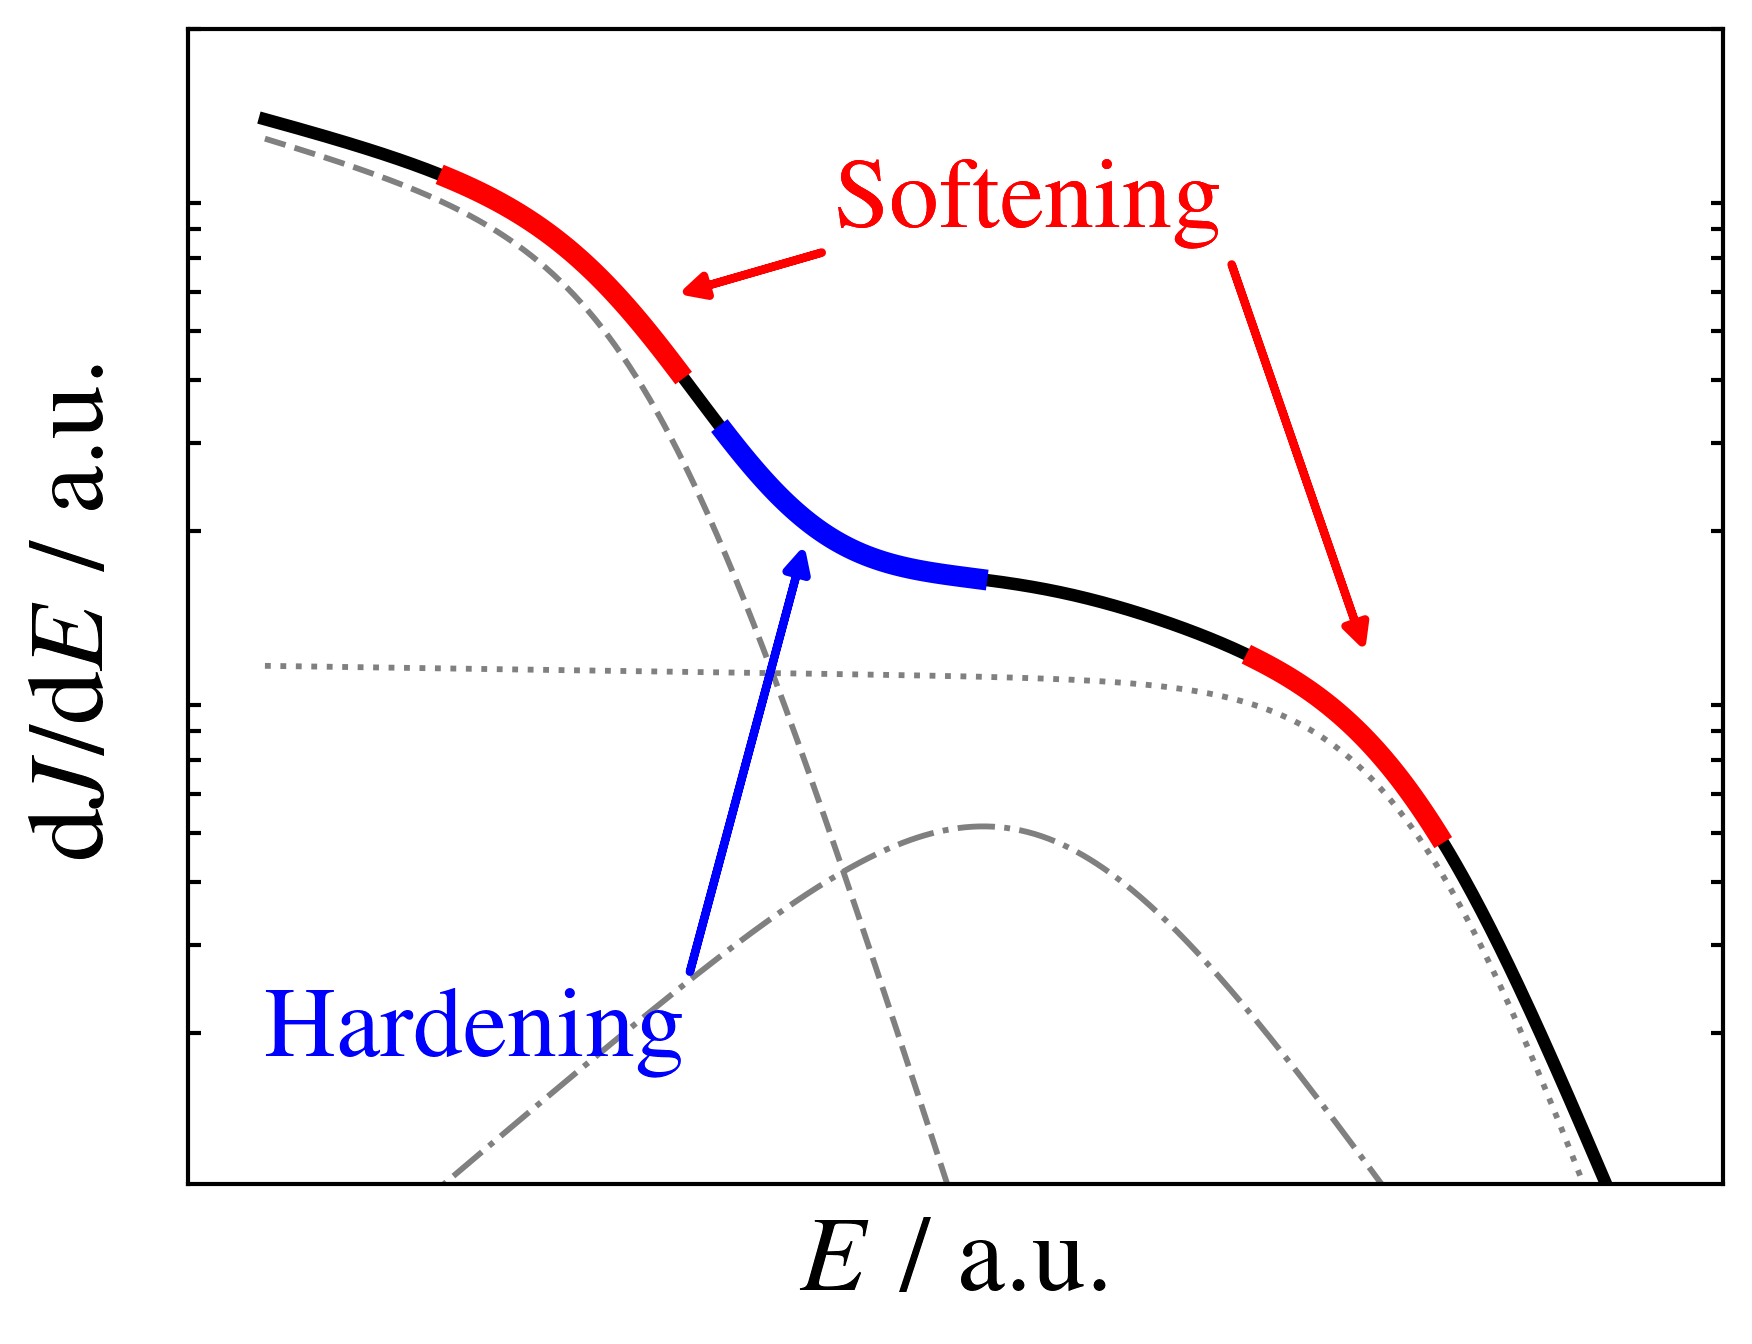

In [10]:
set_plt_style("double tex")

w1, k1, x1 = 10, 100, 3.85
w2, k2, x2 = 0.5, 100, 3.95
w3, k3, x3 = 50, 80, 3.9

X = np.linspace(3.8, 4.1, 1000)
proton = lambda x: np.exp(-w1 * (x-x1) + 2) * (1-1/(1 + np.exp(-k1*(x-x1))))
iron = lambda x: np.exp(-w2 * (x-x2)) * (1-1/(1 + np.exp(-k2*(x-x2))))
extragalactic = lambda x: np.exp(-w3 * (x-x3)) * 1/(1 + np.exp(-k3*(x-x3)))
SUM = proton(X) + iron(X) + extragalactic(X)

plt.plot(X, SUM, marker='none', zorder=10, lw=1.5, label='Sum')
plt.plot(X, proton(X), marker='none', lw=0.7, label='Pop. 1', c='gray')
plt.plot(X, iron(X), marker='none', lw=0.7, label='Pop. 2', c='gray')
plt.plot(X, extragalactic(X), marker='none', lw=0.7, label='Pop. 3', c='gray')

plt.ylim(bottom=1e-1, top=20)
plt.xlim(3.79, 3.99)
plt.ylabel("$\mathrm{d}J$/$\mathrm{d}E$ / a.u.")
plt.xlabel("$E$ / a.u.")
plt.yscale("log")
# plt.legend(loc='lower left')

for xy in [ (3.855, 6), (3.943, 1.2)]:
    plt.annotate("Softening", xy, xytext=(3.9, 9),
                 fontsize=12,
                    verticalalignment='center',
                    horizontalalignment='center',
                    arrowprops={'width': 0.025, 'headwidth': 2.5,
                                'headlength': 2.5, 'color':'r'}, c='r')

plt.annotate("Hardening", (3.87, 1.8), xytext=(3.8, 0.2),
                 verticalalignment='center',
                 horizontalalignment='left',
                 fontsize=12,
                 arrowprops={'width': 0.025, 'headwidth': 2.5,
                             'headlength': 2.5, 'color':'b'}, c='b')


first_softening = slice(80, 180)
first_hardening = slice(200, 310)
second_softening = slice(430, 510)

plt.plot(X[first_softening], SUM[first_softening], marker='none', zorder=10, lw=2.5, c='r', ls='-')
plt.plot(X[first_hardening], SUM[first_hardening], marker='none', zorder=10, lw=2.5, c='b', ls='-')
plt.plot(X[second_softening], SUM[second_softening], marker='none', zorder=10, lw=2.5, c='r', ls='-')

plt.yticks([])
plt.xticks([])